In [ ]:
!pip install scipy scikit-learn pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import json

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CareerCorpus_DynamicGT.csv to CareerCorpus_DynamicGT.csv
Saving complete_results.json to complete_results.json
Saving evaluation_results.csv to evaluation_results.csv


In [ ]:
dynamic_gt = pd.read_csv("CareerCorpus_DynamicGT.csv")

eval_df = pd.read_csv("evaluation_results.csv")

with open("complete_results.json","r") as f:
    json_results = json.load(f)

print(dynamic_gt.shape)
print(eval_df.shape)
print(len(json_results))

(302, 12)
(302, 6)
302


In [ ]:
print(dynamic_gt.columns)

print(eval_df.columns)

Index(['ID', 'Domain', 'Education', 'Skills and Achievements', 'Experience',
       'Job_type', 'Annotator-1', 'Annotator-2', 'Resume_Text',
       'Weight_Annotator1', 'Weight_Annotator2', 'Dynamic_GT'],
      dtype='object')
Index(['resume_id', 'domain', 'predicted_score', 'ground_truth_score',
       'decision', 'reasoning'],
      dtype='object')


In [ ]:
dynamic_gt["Dynamic_GT"] = dynamic_gt["Dynamic_GT"] * 10

dynamic_gt[["ID","Dynamic_GT"]].head()

,ID,Dynamic_GT
0,74552449,8.611765
1,79041971,6.439394
2,77156708,9.338889
3,24580361,9.022581
4,34953092,8.486956


In [ ]:
gt_map = dict(zip(dynamic_gt["ID"], dynamic_gt["Dynamic_GT"]))

print("Total IDs:",len(gt_map))

Total IDs: 301


In [ ]:
eval_df["ground_truth_score"] = eval_df["resume_id"].map(gt_map)

eval_df.head()

,resume_id,domain,predicted_score,ground_truth_score,decision,reasoning
0,74552449,Banking,7.5,8.611765,Hold,The candidate has a strong educational backgro...
1,79041971,Banking,6.5,6.439394,Hold,The candidate has a strong background in leade...
2,77156708,Banking,8.5,9.338889,Hire,The candidate has a strong educational backgro...
3,24580361,Banking,7.5,9.022581,Hold,The candidate has a strong educational backgro...
4,34953092,Banking,9.0,8.486956,Hire,The candidate has a strong educational backgro...


In [ ]:
print("Missing values:",
      eval_df["ground_truth_score"].isnull().sum())

Missing values: 0


In [ ]:
eval_df.to_csv(
    "evaluation_results_dynamicGT.csv",
    index=False
)

print("Updated CSV Saved")

Updated CSV Saved


In [ ]:
for item in json_results:

    rid = item["resume_id"]

    if rid in gt_map:
        item["ground_truth_score"] = float(gt_map[rid])

with open("complete_results_dynamicGT.json","w") as f:
    json.dump(json_results,f,indent=4)

print("Updated JSON Saved")

Updated JSON Saved


In [ ]:
y_true = eval_df["ground_truth_score"].astype(float).values

y_pred = eval_df["predicted_score"].astype(float).values

print("Samples:",len(y_true))

Samples: 302


In [ ]:
pearson_corr,_ = pearsonr(y_true,y_pred)

print("Pearson Correlation =",round(pearson_corr,4))

Pearson Correlation = 0.5986


In [ ]:
spearman_corr,_ = spearmanr(y_true,y_pred)

print("Spearman Correlation =",round(spearman_corr,4))

Spearman Correlation = 0.6188


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.read_csv("evaluation_results_dynamicGT.csv")

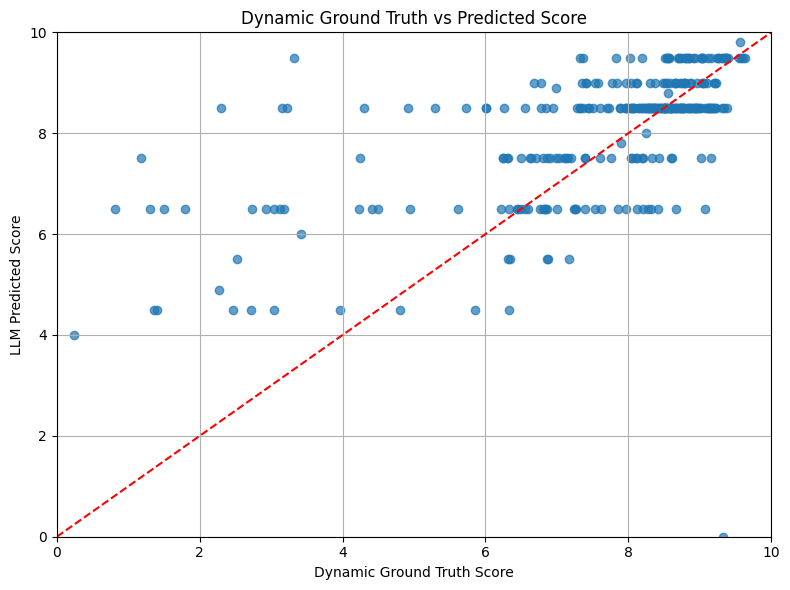

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["ground_truth_score"],
    plot_df["predicted_score"],
    alpha=0.7
)

plt.plot([0,10],[0,10],'r--')

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("LLM Predicted Score")
plt.title("Dynamic Ground Truth vs Predicted Score")

plt.xlim(0,10)
plt.ylim(0,10)

plt.grid(True)
plt.tight_layout()
plt.show()

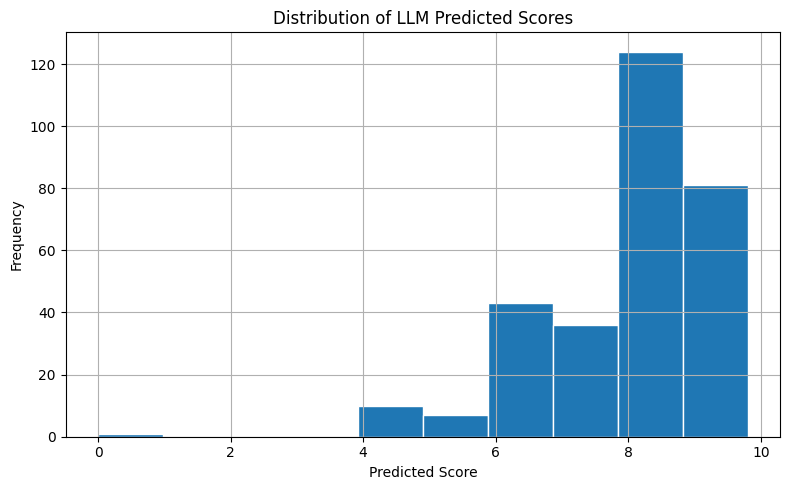

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    plot_df["predicted_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Distribution of LLM Predicted Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

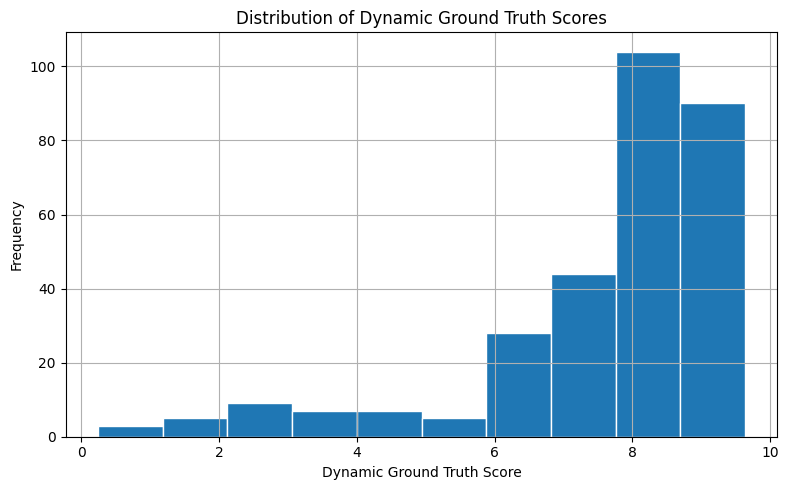

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    plot_df["ground_truth_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Ground Truth Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

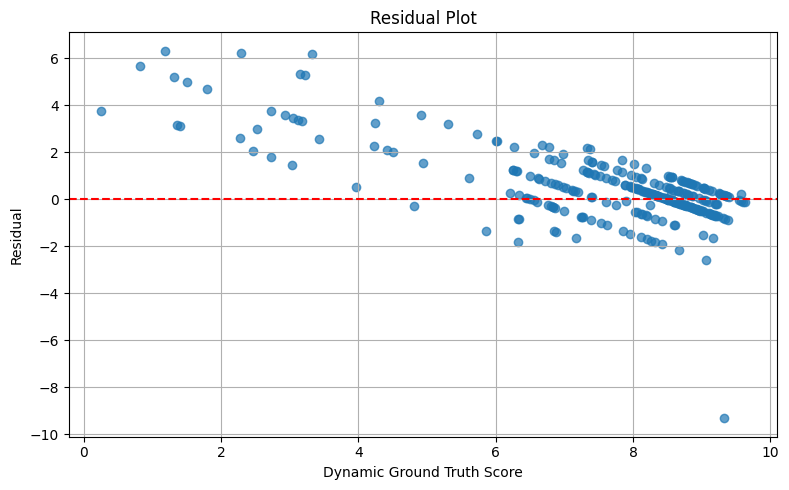

In [ ]:
residuals = (
    plot_df["predicted_score"] -
    plot_df["ground_truth_score"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df["ground_truth_score"],
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.tight_layout()
plt.show()

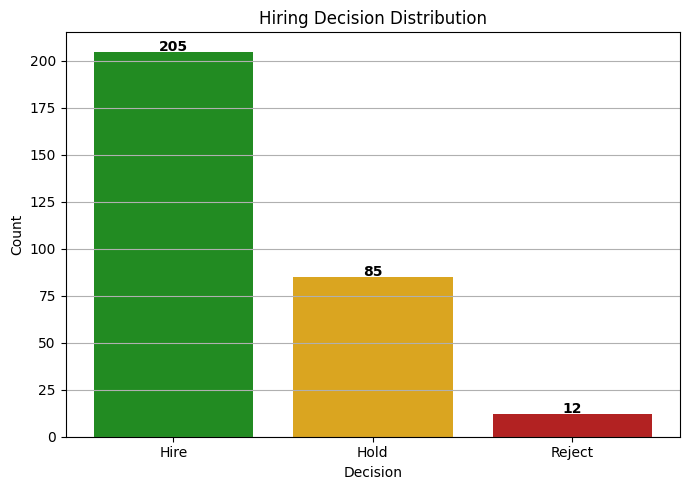

In [ ]:
decision_counts = plot_df["decision"].value_counts()

colors = {
    "Hire": "forestgreen",
    "Hold": "goldenrod",
    "Reject": "firebrick"
}

plt.figure(figsize=(7,5))

bars = plt.bar(
    decision_counts.index,
    decision_counts.values,
    color=[colors.get(i, "gray") for i in decision_counts.index]
)

plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Hiring Decision Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [30]:
plot_df = pd.read_csv("evaluation_results_dynamicGT.csv")

In [31]:
# ============================================================
# PERFORMANCE METRICS (Dynamic Ground Truth)
# ============================================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

gt = plot_df["ground_truth_score"]
pred = plot_df["predicted_score"]

# ------------------------------------------------------------
# Overall Correlations
# ------------------------------------------------------------

pearson_corr, _ = pearsonr(gt, pred)
spearman_corr, _ = spearmanr(gt, pred)

# ------------------------------------------------------------
# Percentile Metrics (Paper Method)
# ------------------------------------------------------------

def percentile_metrics(df, percentile):

    gt = df["ground_truth_score"]
    pred = df["predicted_score"]

    lower = np.percentile(gt, percentile)
    upper = np.percentile(gt, 100 - percentile)

    subset = df[
        (gt <= lower) |
        (gt >= upper)
    ]

    pc = pearsonr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )[0]

    sc = spearmanr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )[0]

    return pc, sc

PC20, SC20 = percentile_metrics(plot_df,20)
PC15, SC15 = percentile_metrics(plot_df,15)
PC10, SC10 = percentile_metrics(plot_df,10)

# ------------------------------------------------------------
# Error Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(gt, pred)

rmse = np.sqrt(
    mean_squared_error(gt, pred)
)

r2 = r2_score(gt, pred)

# ------------------------------------------------------------
# Print Results
# ------------------------------------------------------------

print("\nOverall Correlations")
print(f"Pearson Correlation : {pearson_corr:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")

print("\nPercentile Metrics")
print(f"PC20 : {PC20:.4f}")
print(f"SC20 : {SC20:.4f}")
print(f"PC15 : {PC15:.4f}")
print(f"SC15 : {SC15:.4f}")
print(f"PC10 : {PC10:.4f}")
print(f"SC10 : {SC10:.4f}")

print("\nError Metrics")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("\nDecision Distribution")

decision_counts = plot_df["decision"].value_counts()

for decision, count in decision_counts.items():
    print(f"{decision}: {count} ({count/len(plot_df)*100:.1f}%)")

print("\nScore Statistics")

print(f"Predicted Score Mean   : {pred.mean():.2f}")
print(f"Ground Truth Mean      : {gt.mean():.2f}")

print(f"Predicted Score Std    : {pred.std():.2f}")
print(f"Ground Truth Std       : {gt.std():.2f}")

print("\n" + "=" * 80)
print("Visualization Completed Successfully")
print("=" * 80)

MODEL PERFORMANCE METRICS

Overall Correlations
Pearson Correlation : 0.5986
Spearman Correlation: 0.6188

Percentile Metrics
PC20 : 0.6223
SC20 : 0.7133
PC15 : 0.6143
SC15 : 0.7217
PC10 : 0.6266
SC10 : 0.7641

Error Metrics
MAE  : 0.9730
RMSE : 1.5857
R²   : 0.2877

Decision Distribution
Hire: 205 (67.9%)
Hold: 85 (28.1%)
Reject: 12 (4.0%)

Score Statistics
Predicted Score Mean   : 8.07
Ground Truth Mean      : 7.60
Predicted Score Std    : 1.30
Ground Truth Std       : 1.88

Visualization Completed Successfully
